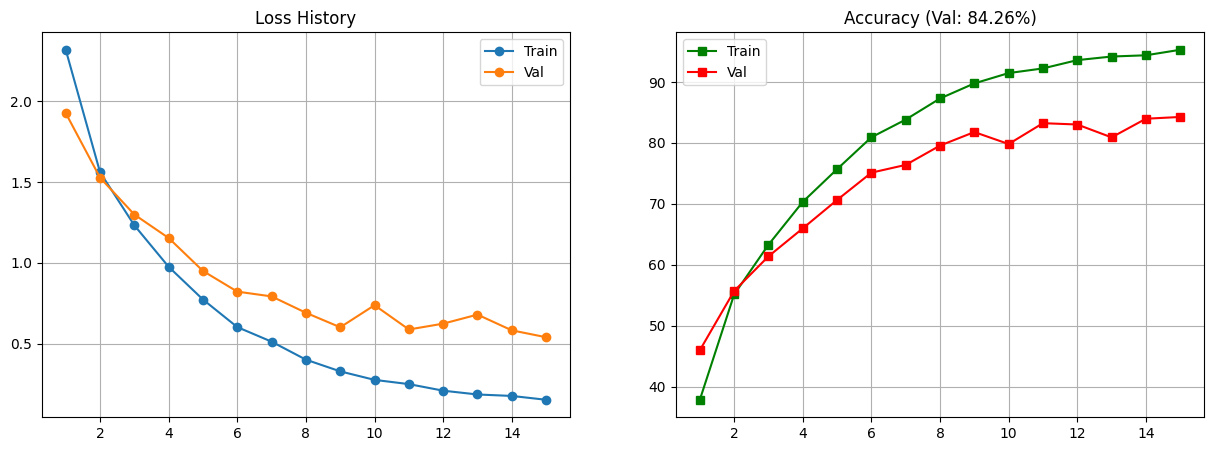

✅ Epoch 15 Completed. Links:


/kaggle/working/food_resnet_epoch_15.pth

/kaggle/working/training_history.pkl

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from IPython import display
from IPython.display import FileLink
from tqdm.auto import tqdm
import pickle

# Force CUDA to report errors immediately
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# ==========================================
# 1. Setup & Hyperparameters
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_PATH = "/kaggle/input/sam-dataset/SAM_dataset" 
NUM_CLASSES = 85 
BATCH_SIZE = 32
TOTAL_EPOCHS = 15
LEARNING_RATE = 0.001
HISTORY_FILE = "training_history.pkl"

# ==========================================
# 2. Dataset Class (With Label Safety)
# ==========================================
class FoodCropDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.split_dir = os.path.join(root_dir, split)
        self.image_dir = os.path.join(self.split_dir, "images")
        self.mask_dir = os.path.join(self.split_dir, "masks")
        self.mask_files = [f for f in os.listdir(self.mask_dir) if f.endswith('.png')]
        self.transform = transform

    def __len__(self): return len(self.mask_files)

    def __getitem__(self, idx):
        try:
            mask_name = self.mask_files[idx]
            mask = np.array(Image.open(os.path.join(self.mask_dir, mask_name)))
            max_val = np.max(mask)
            
            # --- LABEL SAFETY CHECK ---
            class_id = int(max_val) - 1
            if class_id < 0 or class_id >= NUM_CLASSES:
                return self.__getitem__((idx + 1) % len(self))
            
            base_img_name = mask_name.split('_obj')[0]
            img_path = os.path.join(self.image_dir, base_img_name + ".jpg")
            if not os.path.exists(img_path): 
                img_path = os.path.join(self.image_dir, base_img_name + ".png")
            
            image = np.array(Image.open(img_path).convert("RGB"))
            pos = np.where(mask > 0)
            crop = image[np.min(pos[0]):np.max(pos[0])+1, np.min(pos[1]):np.max(pos[1])+1]
            
            crop_pil = Image.fromarray(crop)
            if self.transform: crop_pil = self.transform(crop_pil)
            return crop_pil, class_id
        except:
            return self.__getitem__((idx + 1) % len(self))

# Data Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Loaders
train_loader = DataLoader(FoodCropDataset(DATASET_PATH, "train", transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(FoodCropDataset(DATASET_PATH, "val", transform), batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 3. Model & Specific Resumption Logic
# ==========================================
import re

# Update these to match your current Kaggle Input paths exactly
CHECKPOINT_DATASET_PATH = "/kaggle/input/samdta" 
TARGET_CHECKPOINT = "food_resnet_epoch_6 (1).pth"
TARGET_HISTORY = "training_history (4).pkl"  # Your specific history file

# Initialize Model
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

# Default starting values
START_EPOCH = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# --- 1. Load the Model Weights ---
ckpt_full_path = os.path.join(CHECKPOINT_DATASET_PATH, TARGET_CHECKPOINT)
if os.path.exists(ckpt_full_path):
    print(f"♻️ Loading weights: {ckpt_full_path}")
    model.load_state_dict(torch.load(ckpt_full_path, map_location=DEVICE))
    
    # Extract epoch 6 from filename to set start point
    epoch_match = re.search(r'epoch_(\d+)', TARGET_CHECKPOINT)
    if epoch_match:
        START_EPOCH = int(epoch_match.group(1))
else:
    print(f"⚠️ Warning: {TARGET_CHECKPOINT} not found. Starting from Epoch 0.")

# --- 2. Load the History ---
history_full_path = os.path.join(CHECKPOINT_DATASET_PATH, TARGET_HISTORY)
if os.path.exists(history_full_path):
    print(f"📈 Loading history: {history_full_path}")
    with open(history_full_path, 'rb') as f:
        history = pickle.load(f)
    # Sync history length with START_EPOCH to ensure graph continuity
    for key in history:
        history[key] = history[key][:START_EPOCH]
else:
    print("⚠️ History file not found. Graph will start from current epoch.")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 4. Training Loop (Starting from START_EPOCH)
# ==========================================
# This ensures we start from 6 and go to 15
for epoch in range(START_EPOCH, TOTAL_EPOCHS):
    model.train()
    running_loss, train_correct, train_total = 0.0, 0, 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{TOTAL_EPOCHS} [Train]")
    
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        train_bar.set_postfix(acc=f"{100.*train_correct/train_total:.1f}%")

    # Validation Phase
    model.eval()
    v_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            v_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # Append to history and save
    history['train_loss'].append(running_loss / len(train_loader))
    history['val_loss'].append(v_loss / len(val_loader))
    history['train_acc'].append(100. * train_correct / train_total)
    history['val_acc'].append(100. * val_correct / val_total)
    
    with open(HISTORY_FILE, 'wb') as f:
        pickle.dump(history, f)

    # Live Plotting
    display.clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train')
    ax1.plot(epochs_range, history['val_loss'], 'o-', label='Val')
    ax1.set_title("Loss History"); ax1.legend(); ax1.grid(True)
    
    ax2.plot(epochs_range, history['train_acc'], 's-', color='green', label='Train')
    ax2.plot(epochs_range, history['val_acc'], 's-', color='red', label='Val')
    ax2.set_title(f"Accuracy (Val: {history['val_acc'][-1]:.2f}%)"); ax2.legend(); ax2.grid(True)
    plt.show()

    # Save current results
    ckpt_name = f"food_resnet_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), ckpt_name)
    print(f"✅ Epoch {epoch+1} Completed. Links:")
    display.display(FileLink(ckpt_name))
    display.display(FileLink(HISTORY_FILE))